# NV-Ingest: Python Client Quick Start Guide

This notebook provides a quick start guide to using the NV-Ingest Python API to create a client that interacts with a running NV-Ingest cluster. It will walk through the following:

- Define the task configuration for an NV-Ingest job
- Submit a job to the NV-Ingest cluster and retrieve completed results
- Investigate the multimodal extractions

Specify a few parameters to connect to our nv-ingest cluster and a notional document to guide the examples.

In [1]:
import os

# client config
HTTP_HOST = os.environ.get('HTTP_HOST', "localhost")
HTTP_PORT = os.environ.get('HTTP_PORT', "7670")
TASK_QUEUE = os.environ.get('TASK_QUEUE', "morpheus_task_queue")

# minio config
MINIO_ACCESS_KEY = os.environ.get('MINIO_ACCESS_KEY', "minioadmin")
MINIO_SECRET_KEY = os.environ.get('MINIO_SECRET_KEY', "minioadmin")

# time to wait for job to complete
DEFAULT_JOB_TIMEOUT = 90

# sample input file and output directory
# SAMPLE_PDF = "/workspace/data/multimodal_test.pdf"
SAMPLE_PDF = "/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data_10"

## The NV-Ingest Python Client

In [2]:
from base64 import b64decode
import time

from nv_ingest_client.client import Ingestor

from IPython import display

/home/artemivashchenko/src/infinia-ai-workload-poc/gcp-rag-nim-milvus/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/artemivashchenko/src/infinia-ai-workload-
[nltk_data]     poc/gcp-rag-nim-milvus/.venv/lib/python3.11/site-
[nltk_data]     packages/llama_index/core/_static/nltk_cache...
[nltk_data]   Package punkt_tab is already up-to-date!


Each ingest job includes a set of tasks. These tasks define the operations that will be performed during ingestion. This allows each job to potentially have different ingestion instructions. Here we define a simple extract oriented job, but the full list of supported options are contained below:

- `extract` : Performs multimodal extractions from a document, including text, images, and tables.
- `split` : Chunk the text into smaller chunks, useful for storing in a vector database for retrieval applications.
- `dedup` : Identifies duplicate images in document that can be filtered to remove data redundancy.
- `filter` : Filters out images that are likely not useful using some heuristics, including size and aspect ratio.
- `embed` : Computes an embedding for the extracted content using a [`nvidia/llama-3.2-nv-embedqa-1b-v2`](https://catalog.ngc.nvidia.com/orgs/nim/teams/nvidia/containers/llama-3.2-nv-embedqa-1b-v2) NVIDIA Inference Microservice (NIM) by default.
- `vbd_upload` : Save embeddings, chunks, and metadata to a Milvus vector database.

We'll use the Ingestor interface to chain together an extraction tast and a deduplication task to ingest our sample PDF. 

In [3]:
ingestor = (
    Ingestor(message_client_hostname=HTTP_HOST)
    .load()
    .files(SAMPLE_PDF)
    .extract(
        extract_text=True,
        extract_tables=True,
        extract_charts=True,
        extract_images=True,
        text_depth="page",
    ).dedup(
        content_type="image",
        filter=True,
    )
)

Submit the job to our NV-Ingest cluster

In [4]:
generated_metadata = ingestor.ingest()[0]

In [5]:
generated_metadata

[{'document_type': 'image',
  'metadata': {'content': '...',
   'content_url': '',
   'embedding': None,
   'source_metadata': {'source_name': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1016445.pdf',
    'source_id': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1016445.pdf',
    'source_location': '',
    'source_type': 'PDF',
    'collection_id': '',
    'date_created': '2020-09-30T20:16:10',
    'last_modified': '2021-07-21T20:49:01',
    'summary': '',
    'partition_id': -1,
    'access_level': 1},
   'content_metadata': {'type': 'image',
    'description': 'Image extracted from PDF document.',
    'page_number': 0,
    'hierarchy': {'page_count': 2,
     'page': 0,
     'block': -1,
     'line': -1,
     'span': -1,
     'nearby_objects': {'text': {'content': [], 'bbox': [], 'type': []},
      'images': {'content': [], 'bbox': [], 'type': []},
      'structured': {'content': [], 'bbox': [], 'type

## Explore the Outputs

Let's explore elements of the NV-Ingest output. When data flows through an NV-Ingest pipeline, a number of extractions and transformations are performed. As the data is enriched, it is stored in rich metadata hierarchy. In the end, there will be a list of dictionaries, each of which represents a extracted type of information. The most common elements to extract from a dictionary in this hierarchy are the extracted content and the text representation of this content. The next few cells will demonstrate interacting with the metadata, pulling out these elements, and visualizing them. Note, when there is a `-1` value present, this represents non-applicable positional resolution. Positive numbers represent valid positional data.

For a more complete description of metadata elements, view the data dictionary.

[https://github.com/NVIDIA/nv-ingest/blob/main/docs/content-metadata.md](https://github.com/NVIDIA/nv-ingest/blob/main/docs/content-metadata.md)

In [8]:
def redact_metadata_helper(metadata: dict) -> dict:
    """A simple helper function to redact `metadata["content"]` so improve readability."""
    
    text_metadata_redact = text_metadata.copy()
    text_metadata_redact["content"] = "<---Redacted for readability--->"
    
    return text_metadata_redact

### Explore Output - Text

This cell depicts the full metadata hierarchy for a text extraction with redacted content to ease readability. Notice the following sections are populated with information:

- `content` - The raw extracted content, text in this case - this section will always be populated with a successful job.
- `content_metadata` - Describes the type of extraction and its position in the broader document - this section will always be populated with a successful job.
- `source_metadata` - Describes the source document that is the basis of the ingest job.
- `text_metadata` - Contain information about the text extraction, including detected language, among others - this section will only exist when `metadata['content_metadata']['type'] == 'text'`

In [9]:
# text_metadata = next(d["metadata"] for d in generated_metadata if d["metadata"]["content_metadata"]["type"] == "text")
# redact_metadata_helper(text_metadata)

In [269]:
text_metadata = generated_metadata[3]["metadata"]
redact_metadata_helper(text_metadata)

{'content': '<---Redacted for readability--->',
 'content_url': '',
 'embedding': None,
 'source_metadata': {'source_name': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1016445.pdf',
  'source_id': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1016445.pdf',
  'source_location': '',
  'source_type': 'PDF',
  'collection_id': '',
  'date_created': '2020-09-30T20:16:10',
  'last_modified': '2021-07-21T20:49:01',
  'summary': '',
  'partition_id': -1,
  'access_level': 1},
 'content_metadata': {'type': 'text',
  'description': 'Unstructured text from PDF document.',
  'page_number': 1,
  'hierarchy': {'page_count': 2,
   'page': 1,
   'block': -1,
   'line': -1,
   'span': -1,
   'nearby_objects': {'text': {'content': [], 'bbox': [], 'type': []},
    'images': {'content': [], 'bbox': [], 'type': []},
    'structured': {'content': [], 'bbox': [], 'type': []}}},
  'subtype': ''},
 'audio_metadata': None,
 'tex

View the text extracted from the sample document.

In [267]:
text_metadata['content']

'accounts ps4 #Fortnite freeaccount #free accounts for Fortnite #free accounts on Fortnite #free accounts\r\nFortnite #free Fortnite accounts\r\nfortnite accounts generator\r\nfortnite accounts free\r\nfortnite accounts leak\r\ncodes for fortnite accounts\r\nfortnite accounts generator free\r\nfortnite accounts generator ps4\r\nfortnite accounts ps4\r\nfortnite accounts glitch\r\nfortnite free accounts\r\nfree accounts in fortnite\r\nfree accounts on fortnite\r\nfortnite free accounts codes\r\nfortnite free accounts ps4\r\nfortnite free accounts hack\r\nhow to get free fortnite accounts on nintendo switch\r\nfortnite free accounts glitch\r\nhow to get fortnite free accounts\r\nwebsite for free fortnite accounts\r\nfortnite free accounts nintendo switch\r\nfortnite free accounts generator no verification\r\nfortnite free accounts no verify\r\nfortnite free accounts no verification\r\nfree fortnite accounts xbox one generator\r\ncan you get free fortnite accounts\r\nepic games fortnite f

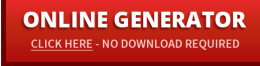

In [263]:
display.Image(b64decode(text_metadata["content"]))

### Explore Output - Tables

This cell depicts the full metadata hierarchy for a table extraction with redacted content to ease readability. Notice the following sections are populated with information:

- `content` - The raw extracted content, a base64 encoded image of the extracted table in this case - this section will always be populated with a successful job.
- `content_metadata` - Describes the type of extraction and its position in the broader document - this section will always be populated with a successful job.
- `source_metadata` - Describes the source and storage path of an extracted table in an S3 compliant object store.
- `table_metadata` - Contains the text representation of the table, positional data, and other useful elements - this section will only exist when `metadata['content_metadata']['type'] == 'structured'`.

Note, `table_metadata` will store chart and table extractions. The are distringuished by `metadata['content_metadata']['subtype']`

In [74]:
table_metadata = next(d["metadata"] for d in generated_metadata if d["metadata"]["content_metadata"]["subtype"] == "table")
redact_metadata_helper(table_metadata)

{'content': '<---Redacted for readability--->',
 'content_url': '',
 'embedding': None,
 'source_metadata': {'source_name': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1479052.pdf',
  'source_id': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1479052.pdf',
  'source_location': '',
  'source_type': 'PDF',
  'collection_id': '',
  'date_created': '2021-06-14T11:35:14',
  'last_modified': '2021-06-14T11:35:14',
  'summary': '',
  'partition_id': -1,
  'access_level': 1},
 'content_metadata': {'type': 'text',
  'description': 'Unstructured text from PDF document.',
  'page_number': 0,
  'hierarchy': {'page_count': 3,
   'page': 0,
   'block': -1,
   'line': -1,
   'span': -1,
   'nearby_objects': {'text': {'content': [], 'bbox': [], 'type': []},
    'images': {'content': [], 'bbox': [], 'type': []},
    'structured': {'content': [], 'bbox': [], 'type': []}}},
  'subtype': ''},
 'audio_metadata': None,
 'tex

Visualize the table contained within the extracted metadata.

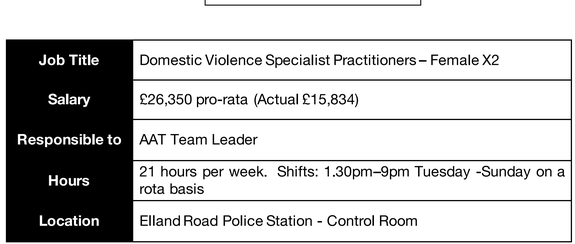

In [75]:
display.Image(b64decode(table_metadata["content"]))

View the corresponding text that maps to this table. This text could be embedded to support multimodal retrieval workflows.

In [76]:
table_metadata["table_metadata"]["table_content"]

'| JobTitle | Domestic Violence SpecialistPractitioners-Female X2 |\n| Salary | 26,350 pro-rataActual 15,834 |\n| Responsible to | AAT Team Leader |\n| Hours | 21 hours per week. | rota basis | Shifts:1.30pm-9pm Tuesday-Sunday on a |\n| Location | Elland Road Police |\n'

### Explore Output - Charts

This cell depicts the full metadata hierarchy for a chart extraction with redacted content to ease readability. Notice the following sections are populated with information:

- `content` - The raw extracted content, a base64 encoded image of the extracted chart in this case - this section will always be populated with a successful job.
- `content_metadata` - Describes the type of extraction and its position in the broader document - this section will always be populated with a successful job.
- `source_metadata` - Describes the source and storage path of an extracted chart in an S3 compliant object store.
- `table_metadata` - Contains the text representation of the chart, positional data, and other useful elements - this section will only exist when `metadata['content_metadata']['type'] == 'structured'`.

Note, `table_metadata` will store chart and table extractions. The are distringuished by `metadata['content_metadata']['subtype']`

In [78]:
chart_metadata = next(d["metadata"] for d in generated_metadata if d["metadata"]["content_metadata"]["type"] == "chart")
chart_metadata_redact = chart_metadata.copy()
chart_metadata_redact["content"] = "<---Redacted for readability--->"
chart_metadata_redact

StopIteration: 

Visualize the chart contained within the extracted metadata.

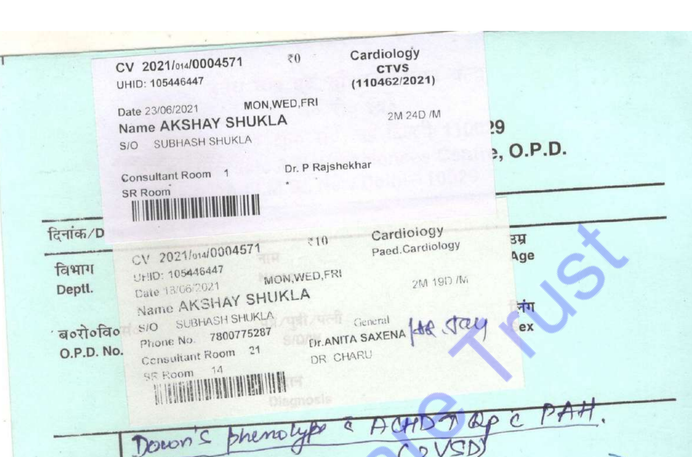

In [63]:
display.Image(b64decode(chart_metadata["content"]))

View the corresponding text that maps to this chart. This text could be embedded to support multimodal retrieval workflows.

In [64]:
chart_metadata["table_metadata"]["table_content"]

"Qee - Qee - PAH      710 - 2M24D/M - 19 - O.P.D. - ex fa-ich/D - oofao O.P.D.No. - faamr Deptl. - Name AKSHAY SHUKLA SUBHASH SHUKLA - CV 2021/014/0004571 UHID:105446447 - Consultant Room SR Room - Towon's - CV2021/014/0004571 - D:105446447 - Cate13/C6/2021 Name AKSHAY SHUKLA - SIO - Name AKSHAY SHUKLA - Phone No.7 - Ccnsuitant Room 21 - 95Room - SUBHASH SHUKLA - 7800775287 - Bhenolyfo - MON.WED.FRI - Ccnsuitant Room 21 - MON.WED.FRI - Dr.P Rajshekhar - Dr.ANITA SAXENA - DR CHARU - ACHD - Cardiology CTVS (110462/2021) - Gieneral - Cardioiogy Paed.Cardiology - COVSD - 2M19D - 34 - Age - ust"

### Explore Output - Images

This cell depicts the full metadata hierarchy for a image extraction with redacted content to ease readability. Notice the following sections are populated with information:

- `content` - The raw extracted content, a base64 encoded image extracted from the document in this case - this section will always be populated with a successful job.
- `content_metadata` - Describes the type of extraction and its position in the broader document - this section will always be populated with a successful job.
- `source_metadata` - Describes the source and storage path of an extracted image in an S3 compliant object store.
- `image_metadata` - Contains the image type, positional data, and other useful elements - this section will only exist when `metadata['content_metadata']['type'] == 'image'`.

In [208]:
img_metadata = next(d["metadata"] for d in generated_metadata if d["metadata"]["content_metadata"]["type"] == "image")
redact_metadata_helper(img_metadata)

{'content': '<---Redacted for readability--->',
 'content_url': '',
 'embedding': None,
 'source_metadata': {'source_name': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1037700.pdf',
  'source_id': '/home/artemivashchenko/src/infinia-ai-workload-poc/nv-ingest-ddn/evaluation/data/bo20/1037700.pdf',
  'source_location': '',
  'source_type': 'PDF',
  'collection_id': '',
  'date_created': '2020-06-17T17:19:06',
  'last_modified': '2020-06-17T17:19:06',
  'summary': '',
  'partition_id': -1,
  'access_level': 1},
 'content_metadata': {'type': 'structured',
  'description': 'Structured chart extracted from PDF document.',
  'page_number': 15,
  'hierarchy': {'page_count': 24,
   'page': 15,
   'block': -1,
   'line': -1,
   'span': -1,
   'nearby_objects': {'text': {'content': [], 'bbox': [], 'type': []},
    'images': {'content': [], 'bbox': [], 'type': []},
    'structured': {'content': [], 'bbox': [], 'type': []}}},
  'subtype': 'chart'},
 'audio

Visualize the image contained within the extracted metadata.

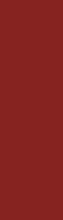

In [206]:
display.Image(b64decode(img_metadata["content"]))

### Optional:  Expanded Task Configuration

This section illustrates usage of the remaining task types used when supporting retrieval workflows.

- `filter` : Filters out images that are likely not useful using some heuristics, including size and aspect ratio.
- `split` : Chunk the text into smaller chunks, useful for storing in a vector database for retrieval applications.
- `embed` - Computes an embedding for the extracted content using a [nvidia/llama-3.2-nv-embedqa-1b-v2`](https://catalog.ngc.nvidia.com/orgs/nim/teams/nvidia/containers/llama-3.2-nv-embedqa-1b-v2) NVIDIA Inference Microservice (NIM) by default.
- `vdb_upload` - Inserts ingested content into a Milvus vector database to support retrieval use cases.

Define the ingest job specification. Here the task configuration is expanded, but requires the ancillary services (Embedding NIM, MinIO object stor, and Milvus Vector Database) to be up and running to return metadata back to the client.

In [ ]:
ingestor = (
    Ingestor(message_client_hostname=HTTP_HOST)
    .files(SAMPLE_PDF)
    .extract(
        extract_text=True,
        extract_tables=True,
        extract_charts=True,
        extract_images=True,
        text_depth="page",
    ).dedup(
        content_type="image",
        filter=True,
    ).filter(
        content_type="image",
        min_size=128,
        max_aspect_ratio=5.0,
        min_aspect_ratio=0.2,
        filter=True,
    )
    .split(
        tokenizer="meta-llama/Llama-3.2-1B",
        chunk_size=1024,
        chunk_overlap=150,
    )
    .embed()
    .vdb_upload(
        dense_dim=2048,
        use_boto3=True
    )
)

In [3]:
MULTIMODAL_HTTP_HOST="localhost"
MULTIMODAL_COLLECTION_NAME="nv_ingest_collection"
MULTIMODAL_MILVUS_URL="http://localhost:19530"
MULTIMODAL_BUCKET_ENDPOINT="https://10.168.15.234:8111"
MULTIMODAL_ACCESS_KEY="LNCPH522WKPM08US4H3E"
MULTIMODAL_SECRET_KEY="q9wzLrw7DP4tchCA5yxQHot6tihbKHVsw6OrD19L"
MULTIMODAL_BUCKET_NAME="milvus-db"
MULTIMODAL_EMBEDDING_ENDPOINT="http://localhost:8012/v1"
MULTIMODAL_EMBEDDING_MODEL_NAME="nvidia/llama-3.2-nv-embedqa-1b-v2"

In [4]:
ingestor = Ingestor(
    message_client_hostname=MULTIMODAL_HTTP_HOST
).files(
    SAMPLE_PDF
).extract(
    extract_text=True,
    extract_tables=True,
    extract_charts=True,
    extract_images=True,
    text_depth="document",
).dedup(
    content_type="image",
    filter=True,
).embed(

).vdb_upload(
    collection_name=MULTIMODAL_COLLECTION_NAME,
    milvus_uri=MULTIMODAL_MILVUS_URL,
    dense_dim=2048,
    minio_endpoint=MULTIMODAL_BUCKET_ENDPOINT,
    access_key=MULTIMODAL_ACCESS_KEY,
    secret_key=MULTIMODAL_SECRET_KEY,
    bucket_name=MULTIMODAL_BUCKET_NAME,
)


Submit the job and retrieve the results

In [ ]:
generated_metadata = ingestor.ingest()[0]

Query the Milvus VDB

In [ ]:
from nv_ingest_client.util.milvus import nvingest_retrieval

query = "What is the dog doing and where?"

query_results = nvingest_retrieval(
    [query],
    "nv_ingest_collection",
    hybrid=False,
    embedding_endpoint="http://localhost:8012/v1",
    model_name="nvidia/llama-3.2-nv-embedqa-1b-v2",
    top_k=1,
    gpu_search=True,
)

print(query_results[0])